# Сессионное задание.

**Работу выполнил студент группы М25-555 Хилалов Муслим Зуфарович**

**ПРИМЕЧАНИЕ: работу необходимо запускать на GPU, поскольку некоторые модели кластеризации были взяты из библиотеки cuml, которая предназначена только для работы на GPU.**

## Описание
Целью данной работы является автоматическая кластеризация сигналов, полученных со сцинтилляционного детектора, на основе их параметров. Необходимо разделить 23 479 сигналов на три кластера: два из них соответствуют различным типам частиц (гамма-кванты и нейтроны), а третий — группе аномальных или неидентифицируемых сигналов.

Задача решается методами машинного обучения без учителя с последующей интерпретацией результатов кластеризации.

## Научная и практическая значимость
Современные задачи ядерной энергетики, радиационного контроля, фундаментальной и прикладной физики требуют высокоточной регистрации и анализа излучения различной природы. Важной составляющей этих задач является возможность отделения компонентов ионизирующего излучения, таких как гамма-кванты и нейтроны, в условиях сложного фонового окружения.

Сцинтилляционные детекторы, особенно основанные на органических кристаллах (например, паратерфенил), обладают высокой чувствительностью к подобным видам излучения и активно применяются:

- при контроле состояния отработанного ядерного топлива,
- в системах радиационного мониторинга,
- в физических экспериментах по регистрации антинейтрино и редких событий,
- в медицине и промышленности.

Однако автоматическая классификация сигналов, поступающих с таких детекторов, представляет собой нетривиальную задачу, так как сигналы могут перекрываться, иметь сложную форму, шумы и вариации. Вручную такие объёмы данных (десятки тысяч сигналов) анализировать практически невозможно.

Применение методов машинного обучения, в частности кластеризации, позволяет:

- автоматизировать процесс распознавания сигналов разного типа,
- улучшить точность и стабильность выделения физических компонент,
- выявлять аномальные сигналы и потенциальные неисправности в системе регистрации,
- заложить основу для онлайн-анализа в реальном времени без участия оператора.

Разработка и тестирование эффективных алгоритмов кластеризации в данной области напрямую способствует:
- повышению точности научных измерений,
- улучшению качества систем радиационного контроля и безопасности,
- развитию технологий интеллектуальной обработки сигналов в ядерной и экспериментальной физике.

## Исходные данные

Набор сигналов, каждый из которых описывается вектором признаков (характеристики сигнала: временные параметры, амплитудные показатели, статистические и производные метрики).

## Задача

Кластеризовать сигналы на три кластера:
- Кластер 0 — сигналы, соответствующие первому типу частиц (гамма-кванты или нейтроны),
- Кластер 1 — сигналы, соответствующие второму типу частиц,
- Кластер 2 — сигналы, не поддающиеся однозначной классификации (аномальные, смешанные или выбросы).

## Ход работы

### Загрузка данных и EDA

Импортируем основные для работы библиотеки, зададим SEED для воспроизводимости работы.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.mixture import GaussianMixture

SEED = 0

Импортируем библиотеки для GPU-вычислений. Они пригодятся для работы некоторых методов кластеризации.

In [49]:
import cudf
import cuml

Установим и импортируем библиотеку для оптимизации гиперпараметров Optuna.

In [50]:
!pip install optuna

In [51]:
import optuna

Перед началом работы, положите в директорию проекта файл с датасетом `Run200_Wave_0_1.txt`.

Загрузим данные в среду выполнения. Удалим лишние признаки, соответствующие ненужным метаданным. Переупорядочим колонки, от 0 до 500.

In [3]:
# Data loading

dataset = pd.read_csv('Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
dataset = dataset.drop([0, 1, 2, 3, 504], axis=1)
dataset.columns = list(range(500))
dataset.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,...,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499
0,14820,14823,14824,14822,14818,14820,14824,14822,14820,14820,14820,14822,14824,14820,14828,14819,14822,14822,14820,14822,14820,14819,14820,14821,14815,14830,14824,14825,14820,14820,14824,14822,14817,14825,14820,14814,14822,14823,14824,14820,...,14815,14816,14817,14825,14817,14818,14823,14821,14824,14821,14824,14815,14817,14823,14820,14816,14818,14824,14815,14820,14818,14818,14818,14816,14824,14822,14823,14816,14818,14823,14828,14822,14815,14815,14817,14819,14820,14822,14820,14819
1,14820,14822,14820,14826,14824,14822,14820,14822,14823,14821,14823,14823,14822,14824,14827,14824,14822,14823,14823,14824,14824,14820,14824,14823,14822,14818,14828,14819,14824,14823,14820,14821,14822,14817,14824,14821,14823,14822,14819,14825,...,14818,14820,14824,14816,14819,14828,14820,14821,14824,14817,14818,14819,14820,14820,14822,14826,14824,14815,14819,14820,14820,14821,14819,14825,14822,14819,14824,14827,14817,14824,14828,14817,14824,14822,14824,14819,14820,14819,14822,14820
2,14820,14820,14822,14825,14820,14824,14824,14819,14823,14824,14823,14823,14823,14824,14819,14820,14823,14821,14820,14822,14818,14819,14820,14824,14822,14822,14820,14820,14824,14822,14820,14822,14823,14823,14822,14815,14820,14824,14827,14827,...,14819,14818,14824,14821,14820,14819,14824,14825,14818,14820,14820,14816,14815,14821,14820,14827,14819,14819,14824,14821,14819,14822,14822,14820,14820,14822,14822,14826,14823,14822,14820,14821,14820,14820,14818,14821,14823,14820,14820,14821
3,14828,14822,14818,14824,14824,14822,14820,14822,14824,14820,14820,14824,14826,14821,14818,14826,14820,14824,14824,14822,14823,14820,14819,14820,14820,14823,14820,14824,14823,14820,14823,14825,14827,14822,14818,14828,14824,14828,14820,14822,...,14822,14820,14817,14827,14819,14826,14824,14823,14823,14822,14824,14823,14823,14823,14820,14821,14823,14822,14824,14822,14820,14820,14820,14825,14820,14822,14823,14821,14824,14824,14824,14826,14822,14821,14820,14828,14820,14822,14823,14822
4,14823,14815,14823,14821,14827,14820,14823,14824,14816,14821,14822,14825,14822,14823,14820,14823,14823,14821,14820,14826,14820,14818,14819,14821,14822,14825,14820,14823,14823,14817,14823,14827,14823,14820,14817,14823,14828,14818,14823,14825,...,14820,14816,14819,14824,14819,14819,14820,14820,14823,14819,14820,14822,14823,14822,14817,14821,14820,14821,14817,14824,14820,14817,14820,14817,14823,14823,14820,14823,14820,14819,14820,14820,14823,14828,14824,14820,14824,14824,14822,14825


Проверим данные на количество пропущенных значений. Как видим, пропуски в датасете отсутствуют.

In [4]:
dataset.isna().sum().sum()

np.int64(0)

Построим графики зависимости 100 первых сигналов от времени (время ограничим от 140 до 200 секундной метки). Как видим из графика, в сигналах наблюдается большой провал (импульс) во временном отрезке от 148 до 170.

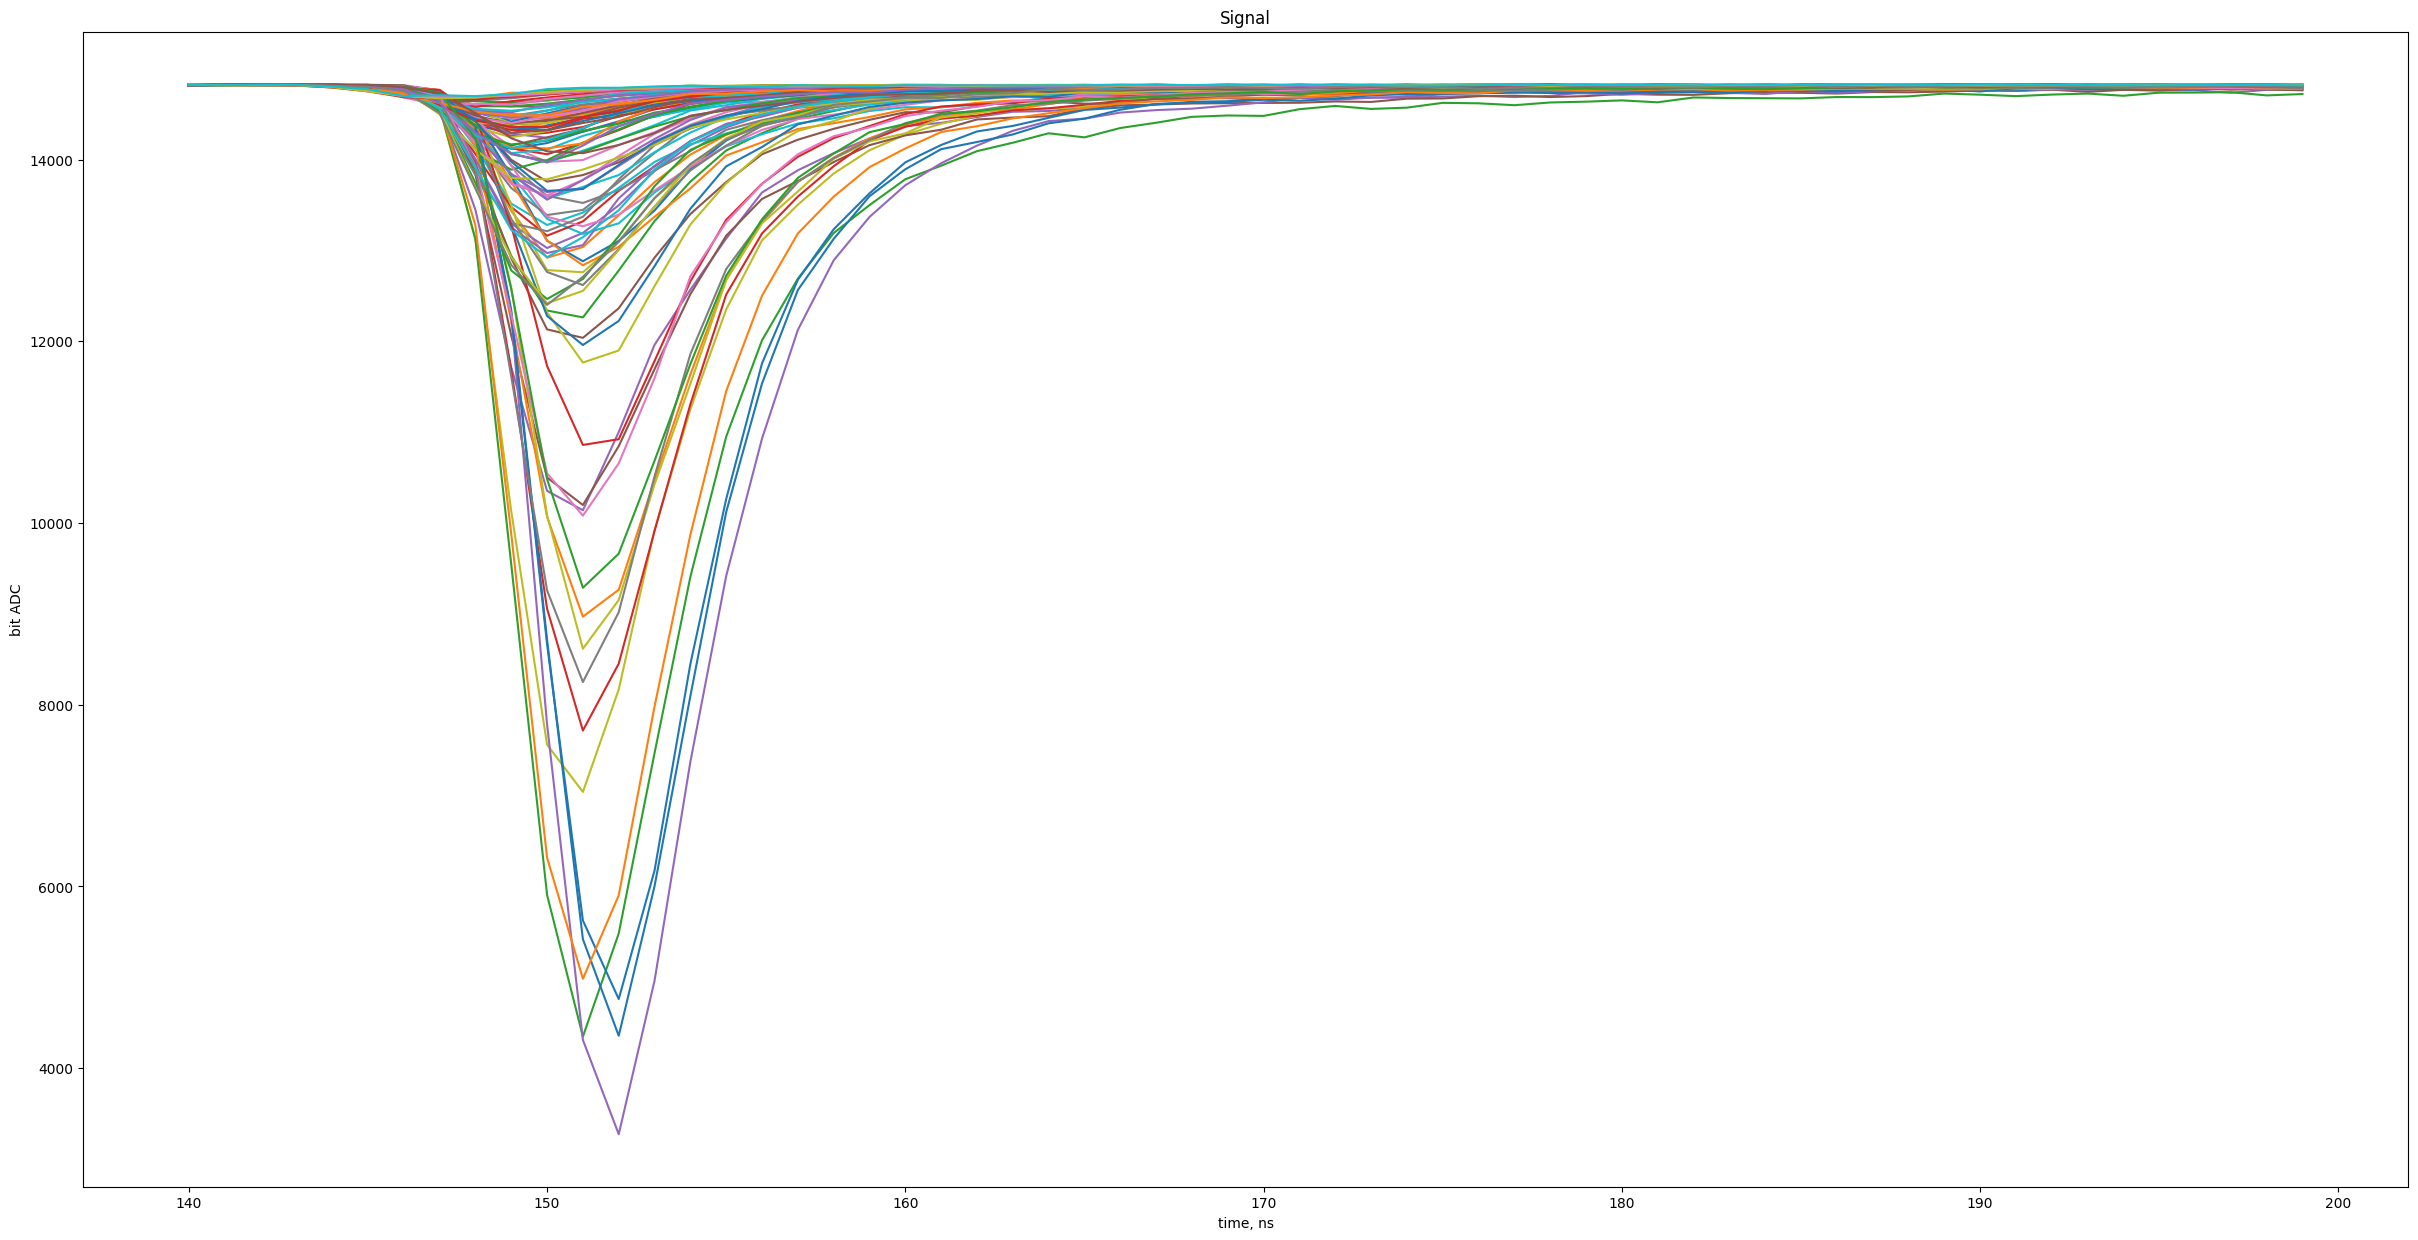

In [11]:
N=range(100)
ax = dataset.T[N][140:200].plot(title='Signal',
                                legend=None,
                                figsize=(30,15))
ax.set_xlabel("time, ns")
ax.set_ylabel("bit ADC");

#### **Вывод**

В результате EDA были подробно исследованы сигналы и сделаны выводы об их поведении на всём временном отрезке (0-500). Примерно на 148-й наносекунде во всех сигналах прослеживается заметный минимум. Но что отличает один сигнал от другого, так это характер его поведения вокруг точки минимума. Это и должно быть опорой при построении возможных новых признаков.

### Предобработка данных

Как мы поняли из этапа EDA, во всех сигналах присутсвует ровно в один и тот же временной период сильный импульс. С такими данными можно работать, но качество будет значительно искажено выбросными значениями.

Для начала преобразуем исходный датасет в NumPy-массив для удобства проведения этапа Feature Engineering.

In [12]:
X = dataset.to_numpy()

Для начала определим baseline для каждого сигнала. Baseline - это характеристика сигнала до появления импульса. Лучше всего будет определить baseline как медиану сигнала до отсчёта времени, равного 120 наносекундам, поскольку там ещё пока мало шума содержится в данных.

Затем вычтем из исходного сигнала его baseline. Так мы получим скорректированные сигналы, которые колеблются около нуля в обычном состоянии, и имеют отрицательное значение в момент импульса. Фактически, мы просто смещаем сигнал вниз относительно оси Y на baseline единиц энергии.

In [13]:
baseline = np.median(X[:,:120], axis=1)[:,None]
X_corr = X - baseline
X_corr.shape

(23479, 500)

Пронормируем каждый сигнал на его амплитуду. Амплитуда здесь рассчитывается как абсолютное значение минимума сигнала (так как импульс сигнала отрицателен).

Нормирование сигналов может помочь в кластеризации, поскольку так мы избавляемся от влияния амплитуды и фокусируемся только на форме сигнала.

In [14]:
amp = np.abs(np.min(X_corr, axis=1))[:,None]
X_norm = X_corr / amp
X_norm.shape

(23479, 500)

Нормированные сигналы теперь можно прогнать через PCA, чтобы уменьшить размерность оси времени (мы можем так делать, поскольку импульсы всех сигналов приходятся на одинаковый промежуток времени).

In [15]:
X_norm_pca = PCA(10, random_state=SEED).fit_transform(X_norm)
X_norm_pca.shape

(23479, 10)

Ещё некоторой информативностью может обладать PSD (Pulse Shape Discrimination) сигнала. Эта величина вычисляется по следующей формуле:

$ PSD = Q_{tail} / Q_{total} $

Здесь $Q_{tail}$ - это величина интеграла энергии в хвосте импульса, а $Q_{total}$ - величина интеграла на всей протяжённости импульса.

Для упрощения, будем вычислять интегралы численно, методом прямоугольника (т.е. просто сумма значений сигнала за фиксированный промежуток времени, т.к. разница между временными метками всегда равна одной наносекунде).

Будем считать (а это видно отчётливо из графиков на этапе EDA), что импульс начинается за 20 наносекунд до точки минимума сигнала, а заканчивается (вся его протяжённость) через 150 наносекунд. Также видим, что хвост импульса начинается через 30 наносекунд после точки минимума сигнала.

Создадим массив, который будет состоять из четырёх признаков для каждого сигнала: интеграл импульса (`q_total`), интеграл хвоста (`q_tail`), PSD (`psd`) и точка минимума (в коде называем `peak`, но для ML-моделей знак не важен). Этот массив будет частью нашего конечно датасета.

In [18]:
def psd_features(x):

    peak = np.argmax(x)

    start = peak - 20
    end = peak + 150
    tail_start = peak + 30

    q_total = np.sum(x[start:end])
    q_tail = np.sum(x[tail_start:end])

    psd = q_tail / q_total

    return np.array([q_total, q_tail, psd, peak])

X_psd = np.array([psd_features(x) for x in -X_corr])
X_psd.shape

(23479, 4)

Объединим теперь получены два набора признаков.

In [21]:
X_input = np.hstack([X_psd, X_norm_pca])
X_input.shape

(23479, 14)

Построим тепловую карту полученных признаков, чтобы проверить, нет ли сильно скоррелированных признаков. Видим, что большую корреляцию имеют первые два признака (т.е. `q_total` и `q_tail`). Но корреляция между ними не превышает 0.9, поэтому не будем их удалять.

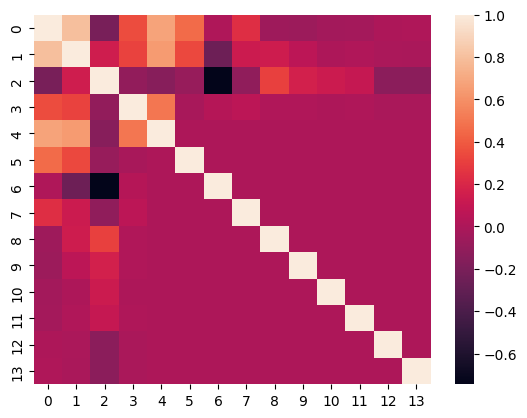

In [22]:
sns.heatmap(pd.DataFrame(X_input).corr());

В нашем полученном датасете разные признаки имеют разный масштаб. Поэтому применим стандартизацию и получим уже финальный датасет для обучения модели.

In [109]:
sc = StandardScaler()
X_final = sc.fit_transform(X_input)

#### **Вывод**

Удалось сократить размерность датасета, уменьшив число столбцов с 500 до 14, при этом оставиви всю самую важную и необходимую для кластеризации сигналов информацию.

### Обучение и подбор гиперпараметров

Сразу определим функцию-утилиту для выгрузки решений. Эта функция выполняет сохранение датафрейма с перестроенными для сабмита метками в файловой системе.

In [80]:
def save_submission(labels, model_name='my', device='cpu'):
    # если используется GPU, то сначала надо перевести в numpy-массив
    if device == 'gpu':
        labels = labels.to_numpy()

    # блок кода переопределения меток для сабмита
    d = {}
    i = 0
    for key in labels:
        if key not in d:
            d[key] = i
            i += 1
    labels = [d[labels[i]] for i in range(labels.shape[0])]

    # создание и выгрузка файла для сабмита в Kaggle
    submit = pd.DataFrame({'index': np.arange(len(labels)),
                           'cluster': labels})
    submit.to_csv(f'{model_name}_submission.csv', index=False)

Также уменьшим размерность нормированного датасета до двух для возможности использования визуализации. Датасет X_visual не будет использоваться для обучения, он нужен будет только для построения графиков.

In [76]:
X_visual = PCA(2, random_state=SEED).fit_transform(X_norm)

#### KMeans

KMeans (а именно его оптимизированная версия MiniBatchKMeans) с гиперпараметром n_clusters=3 даст разбиение на три кластера. По диаграмме рассеяния сможем определить, какой из кластеров будет являться шумовым (label=2).

In [82]:
clusterer = MiniBatchKMeans(n_clusters=3, random_state=SEED)
labels = clusterer.fit_predict(X_final)

Отобразим диаграмму рассеяния точек в уменьшенном пространстве с цветовыми метками, соответствующими полученным меткам кластеров.

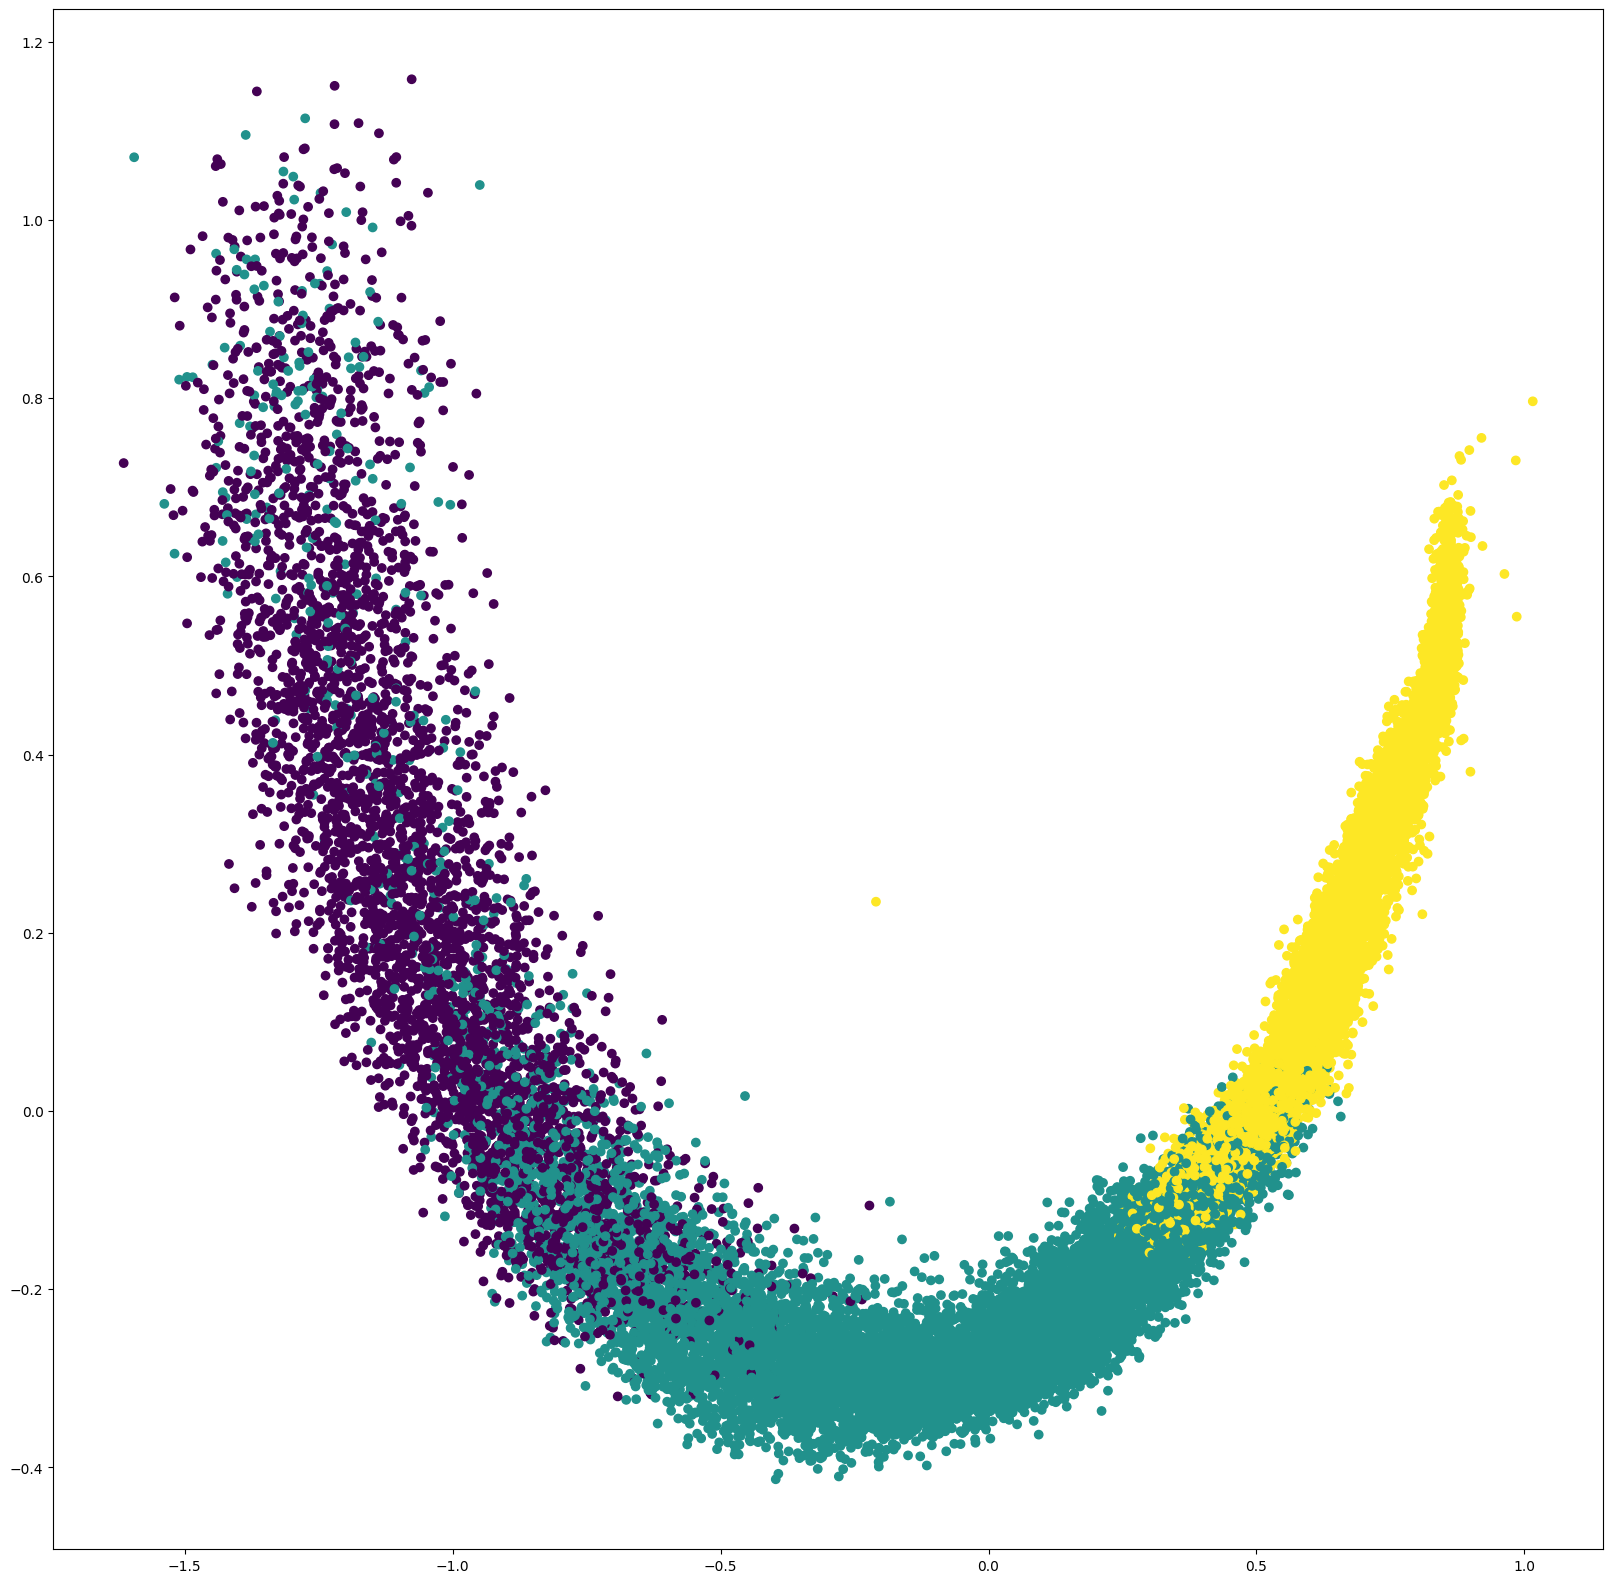

In [83]:
fig, ax = plt.subplots(figsize=(20,20))

ax.scatter(X_visual[:,0], X_visual[:,1], c=labels);

Сохраним метки для сабмита.

In [84]:
save_submission(labels, model_name='kmeans')

Полученная для модели KMeans метрика accuracy на Kaggle:

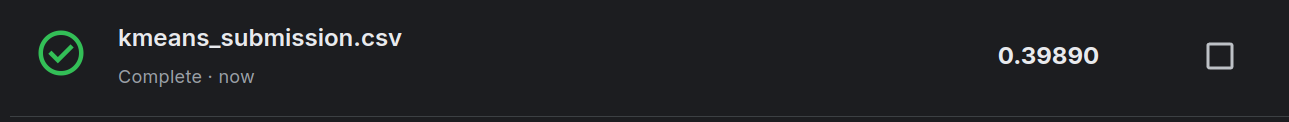

#### GaussianMixture

Обучим GaussinaMixture сначала для трёх компонент.

In [85]:
gmm = GaussianMixture(n_components=3, random_state=SEED)
labels = gmm.fit_predict(X_final)

Отобразим диаграмму рассеяния точек в уменьшенном пространстве с цветовыми метками, соответствующими полученным меткам кластеров.

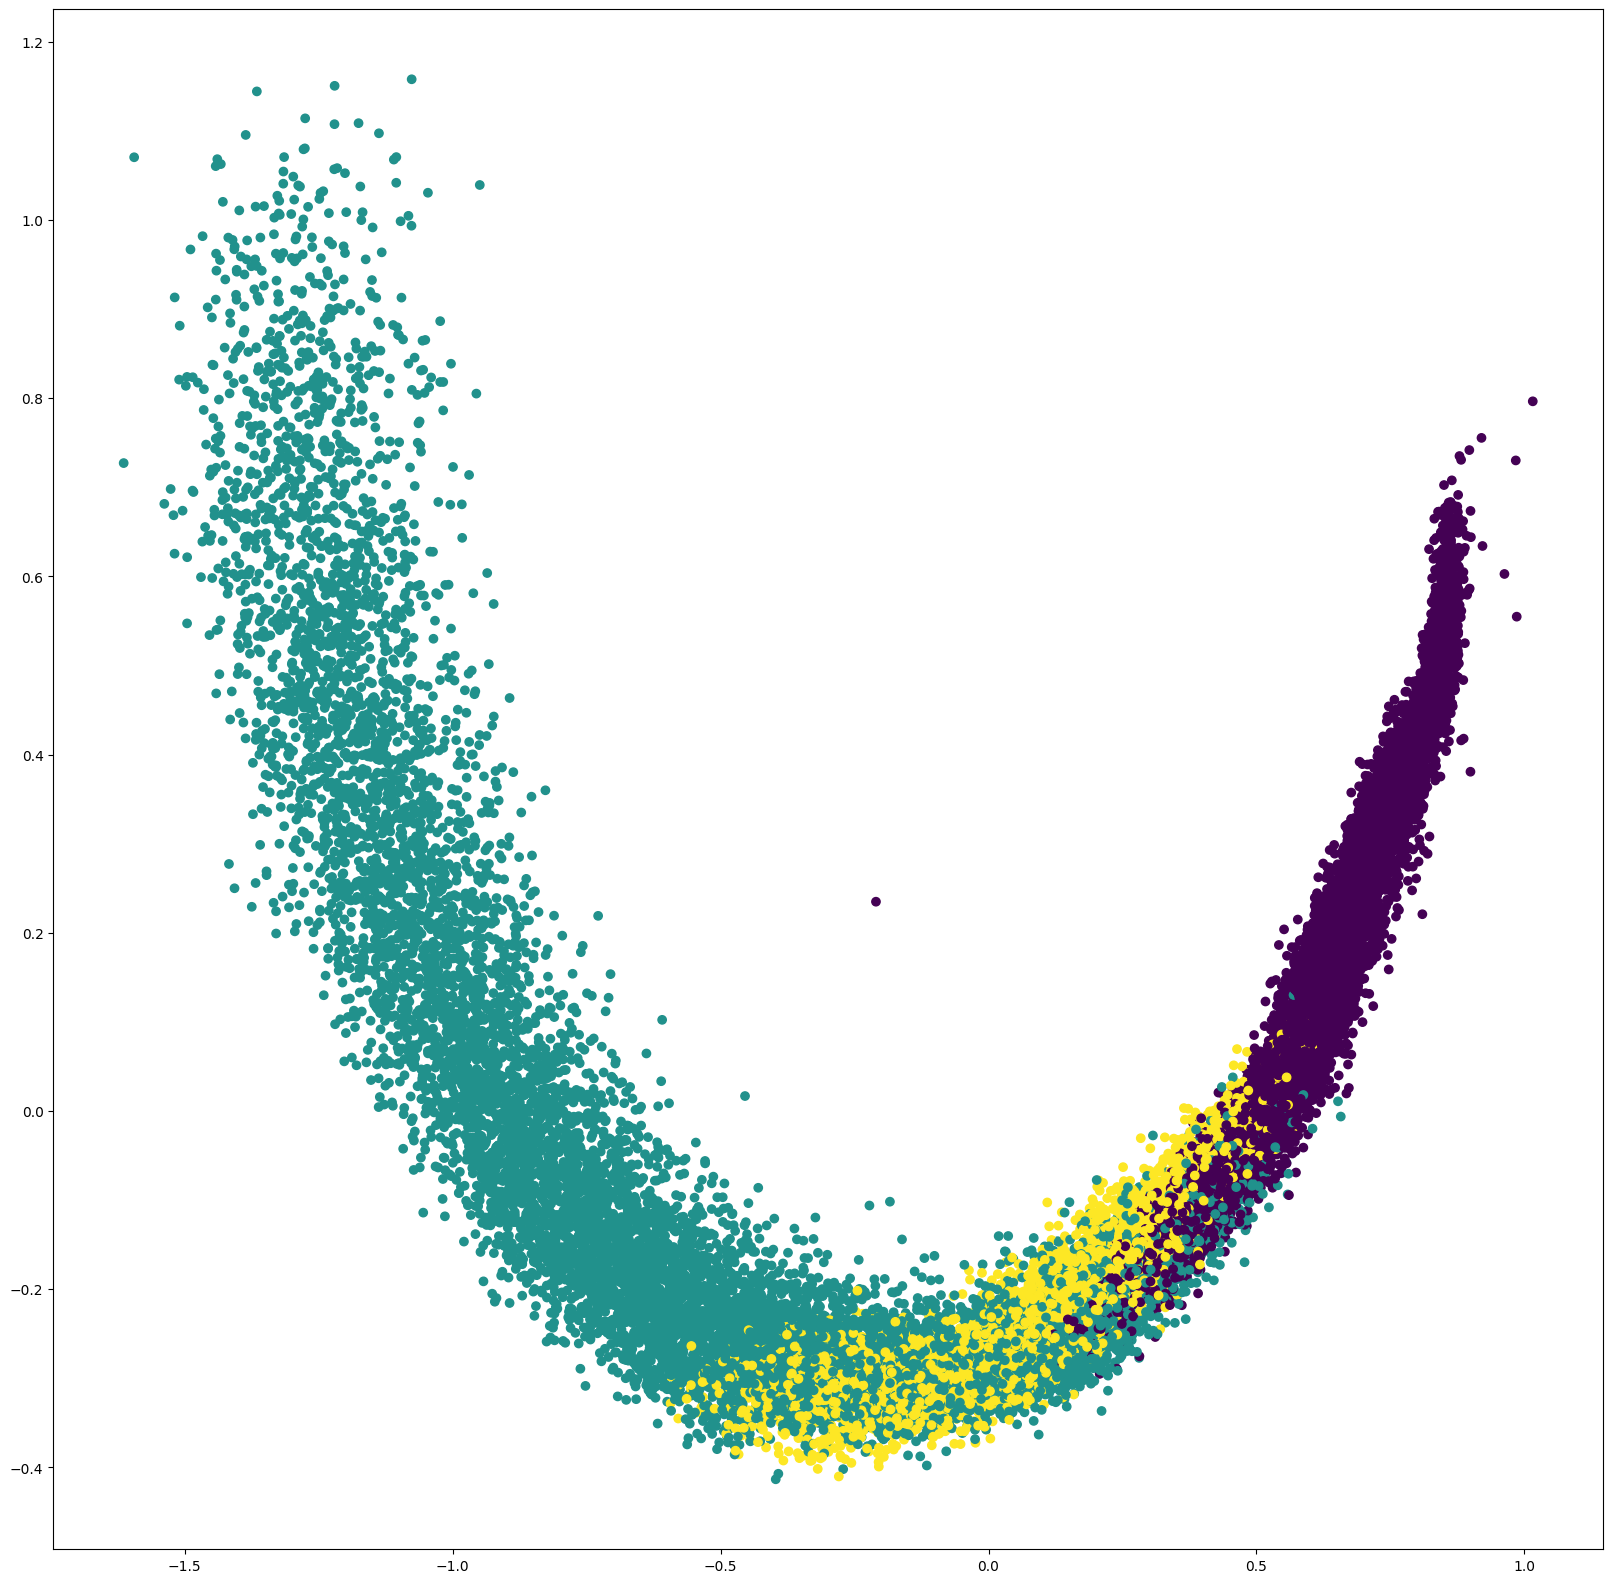

In [86]:
fig, ax = plt.subplots(figsize=(20,20))

ax.scatter(X_visual[:,0], X_visual[:,1], c=labels);

Сохраним метки для сабмита.

In [88]:
save_submission(labels, model_name='mixt_3components')

Полученная для модели GaussianMixtures с тремя компонентами метрика accuracy на Kaggle:

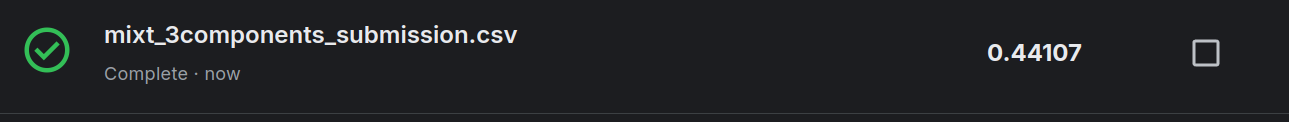

Попробуем разделить данные на две компоненты. Но теперь для сэмплов с неуверенными результатами (т.е. для сэмплов, чьи вероятности для всех компонент меньше 0.8) определим вручную третью, шумовую метку.

In [89]:
gmm = GaussianMixture(n_components=2, random_state=SEED)
labels = gmm.fit_predict(X_final)

In [90]:
p = gmm.predict_proba(X_final)
labels = np.full(len(X_final), 2)

mask = p.max(axis=1) > 0.8
labels[mask] = p[mask].argmax(axis=1)

Отобразим диаграмму рассеяния точек в уменьшенном пространстве с цветовыми метками, соответствующими полученным меткам кластеров.

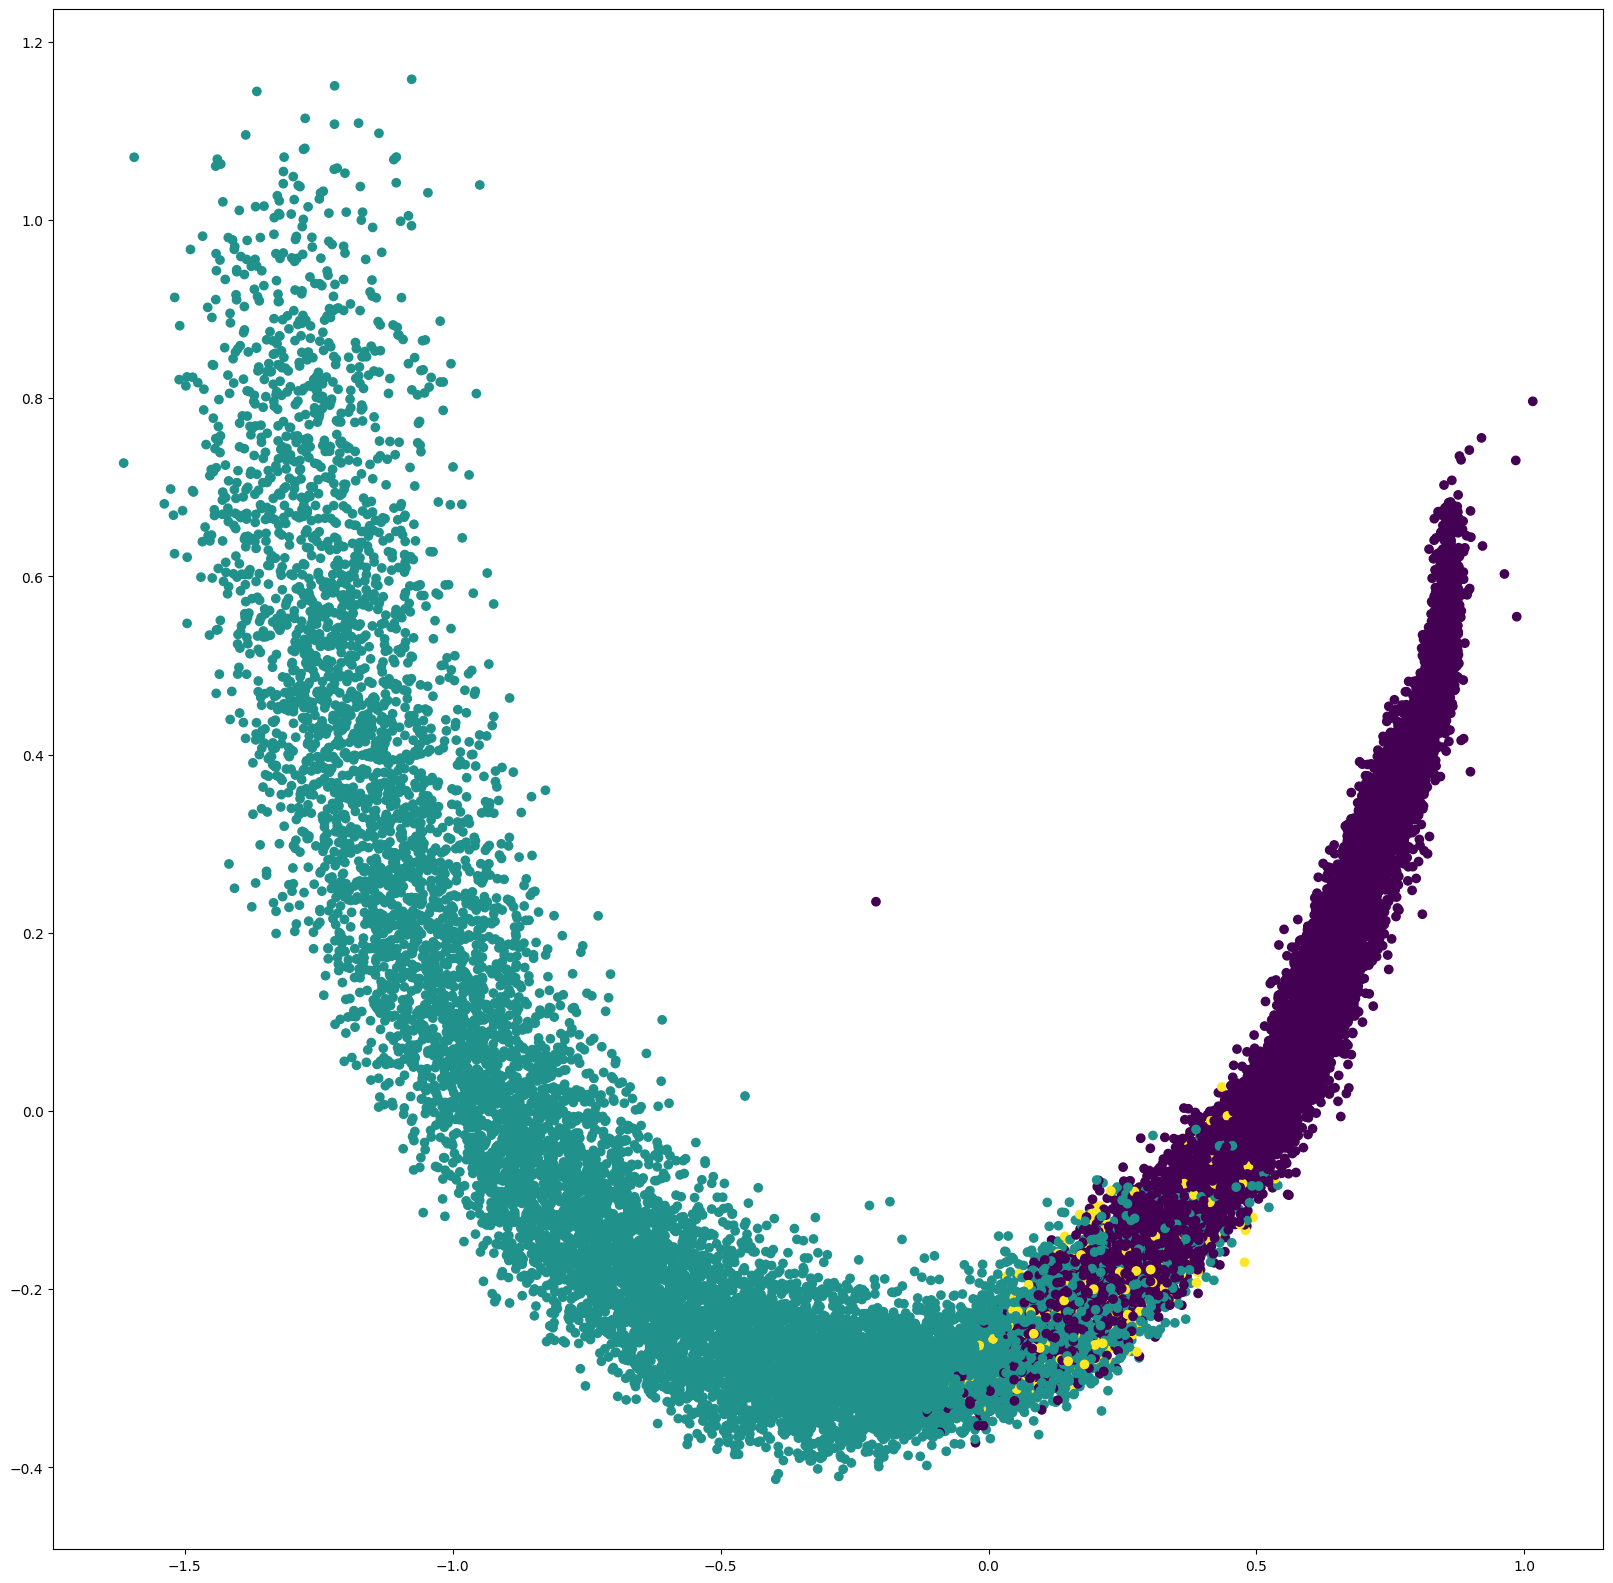

In [91]:
fig, ax = plt.subplots(figsize=(20,20))

ax.scatter(X_visual[:,0], X_visual[:,1], c=labels);

Сохраним метки для сабмита.

In [93]:
save_submission(labels, model_name='mixt_2components')

Полученная для модели GaussianMixtures с двумя компонентами метрика accuracy на Kaggle:

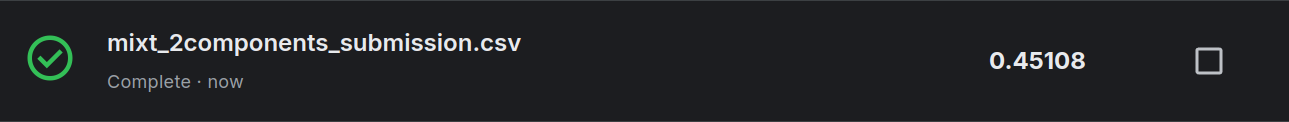

#### HDBSCAN (GPU-версия)

HDBSCAN, в теории, должен сработать лучше всего, поскольку он очень хорошо умеет определять выбросы в данных.

Для подбора гиперпараметров будем использовать библиотеку Optuna.

**ПРИМЕЧАНИЕ**: Весь код ниже для этого метода кластеризации работает только на GPU.

Переведём исходные данные с CPU на GPU.

In [94]:
gpu_df = cudf.from_pandas(pd.DataFrame(X_final))
print(type(gpu_df))

<class 'cudf.core.dataframe.DataFrame'>


Подберём гиперпараметры для HDBSCAN. Будем максимизировать следующее выражение на 100 эпохах:

($ \text{Avg(probabilities)} - 0.5 \ |\text{num_clusters}-2| - 0.5 \ \text{noise_fraction} $) -> $max$.

Здесь:

- probabilities - это вероятности для нешумовых сэмплов (label $\ne -1$)
- num_clusters - полученное число кластеров (не считая шумовой)
- noise_fraction - доля шумовых меток.

In [96]:
def objective(trial, gpu_df):

    clusterer = cuml.cluster.hdbscan.HDBSCAN(
        min_cluster_size=trial.suggest_int('min_cluster_size', 100, 1000),
        min_samples=trial.suggest_int('min_samples', 2, 100),
        alpha=trial.suggest_float('alpha', 1, 10),
        cluster_selection_epsilon=trial.suggest_float('cluster_selection_epsilon', 0, 30)
    )

    labels = clusterer.fit_predict(gpu_df.copy()).to_numpy()

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    mask = labels != -1
    mean_prob = clusterer.probabilities_[mask].mean()
    noise_fraction = (labels == -1).mean()
    return mean_prob - 0.5*abs(n_clusters-2) - 0.5*noise_fraction

study = optuna.create_study(direction='maximize')
study.optimize(lambda trial: objective(trial, gpu_df), n_trials=100, show_progress_bar=True)

[I 2026-06-01 01:34:09,173] A new study created in memory with name: no-name-1822a2ee-2a97-4af7-8c82-52948a6f2345


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-01 01:34:09,370] Trial 0 finished with value: 0.6132966621353961 and parameters: {'min_cluster_size': 397, 'min_samples': 3, 'alpha': 8.707761961304017, 'cluster_selection_epsilon': 6.856984929908746}. Best is trial 0 with value: 0.6132966621353961.
[I 2026-06-01 01:34:09,551] Trial 1 finished with value: 0.5652052580109497 and parameters: {'min_cluster_size': 750, 'min_samples': 21, 'alpha': 8.099100102440548, 'cluster_selection_epsilon': 26.439193127636806}. Best is trial 0 with value: 0.6132966621353961.
[I 2026-06-01 01:34:09,706] Trial 2 finished with value: 0.559532087921228 and parameters: {'min_cluster_size': 677, 'min_samples': 17, 'alpha': 2.4238927441178038, 'cluster_selection_epsilon': 24.292375448653647}. Best is trial 0 with value: 0.6132966621353961.
[I 2026-06-01 01:34:09,938] Trial 3 finished with value: 0.578277135888947 and parameters: {'min_cluster_size': 948, 'min_samples': 89, 'alpha': 3.004014269588156, 'cluster_selection_epsilon': 14.442032965845605}.

Выведем гиперпараметры наилучшей модели HDBSCAN.

In [97]:
study.best_params

{'min_cluster_size': 223,
 'min_samples': 2,
 'alpha': 8.576885645320138,
 'cluster_selection_epsilon': 14.35758364221855}

Обучим наилучшую модель HDBSCAN.

In [98]:
clusterer = cuml.cluster.hdbscan.HDBSCAN(**study.best_params)

labels = clusterer.fit_predict(gpu_df.copy())
labels_numpy = labels.to_numpy()
labels_numpy = np.where(labels_numpy == -1, 2, labels_numpy)
labels.value_counts()

 1    8200
-1    7794
 0    7485
Name: count, dtype: int64

Отобразим диаграмму рассеяния точек в уменьшенном пространстве с цветовыми метками, соответствующими полученным меткам кластеров.

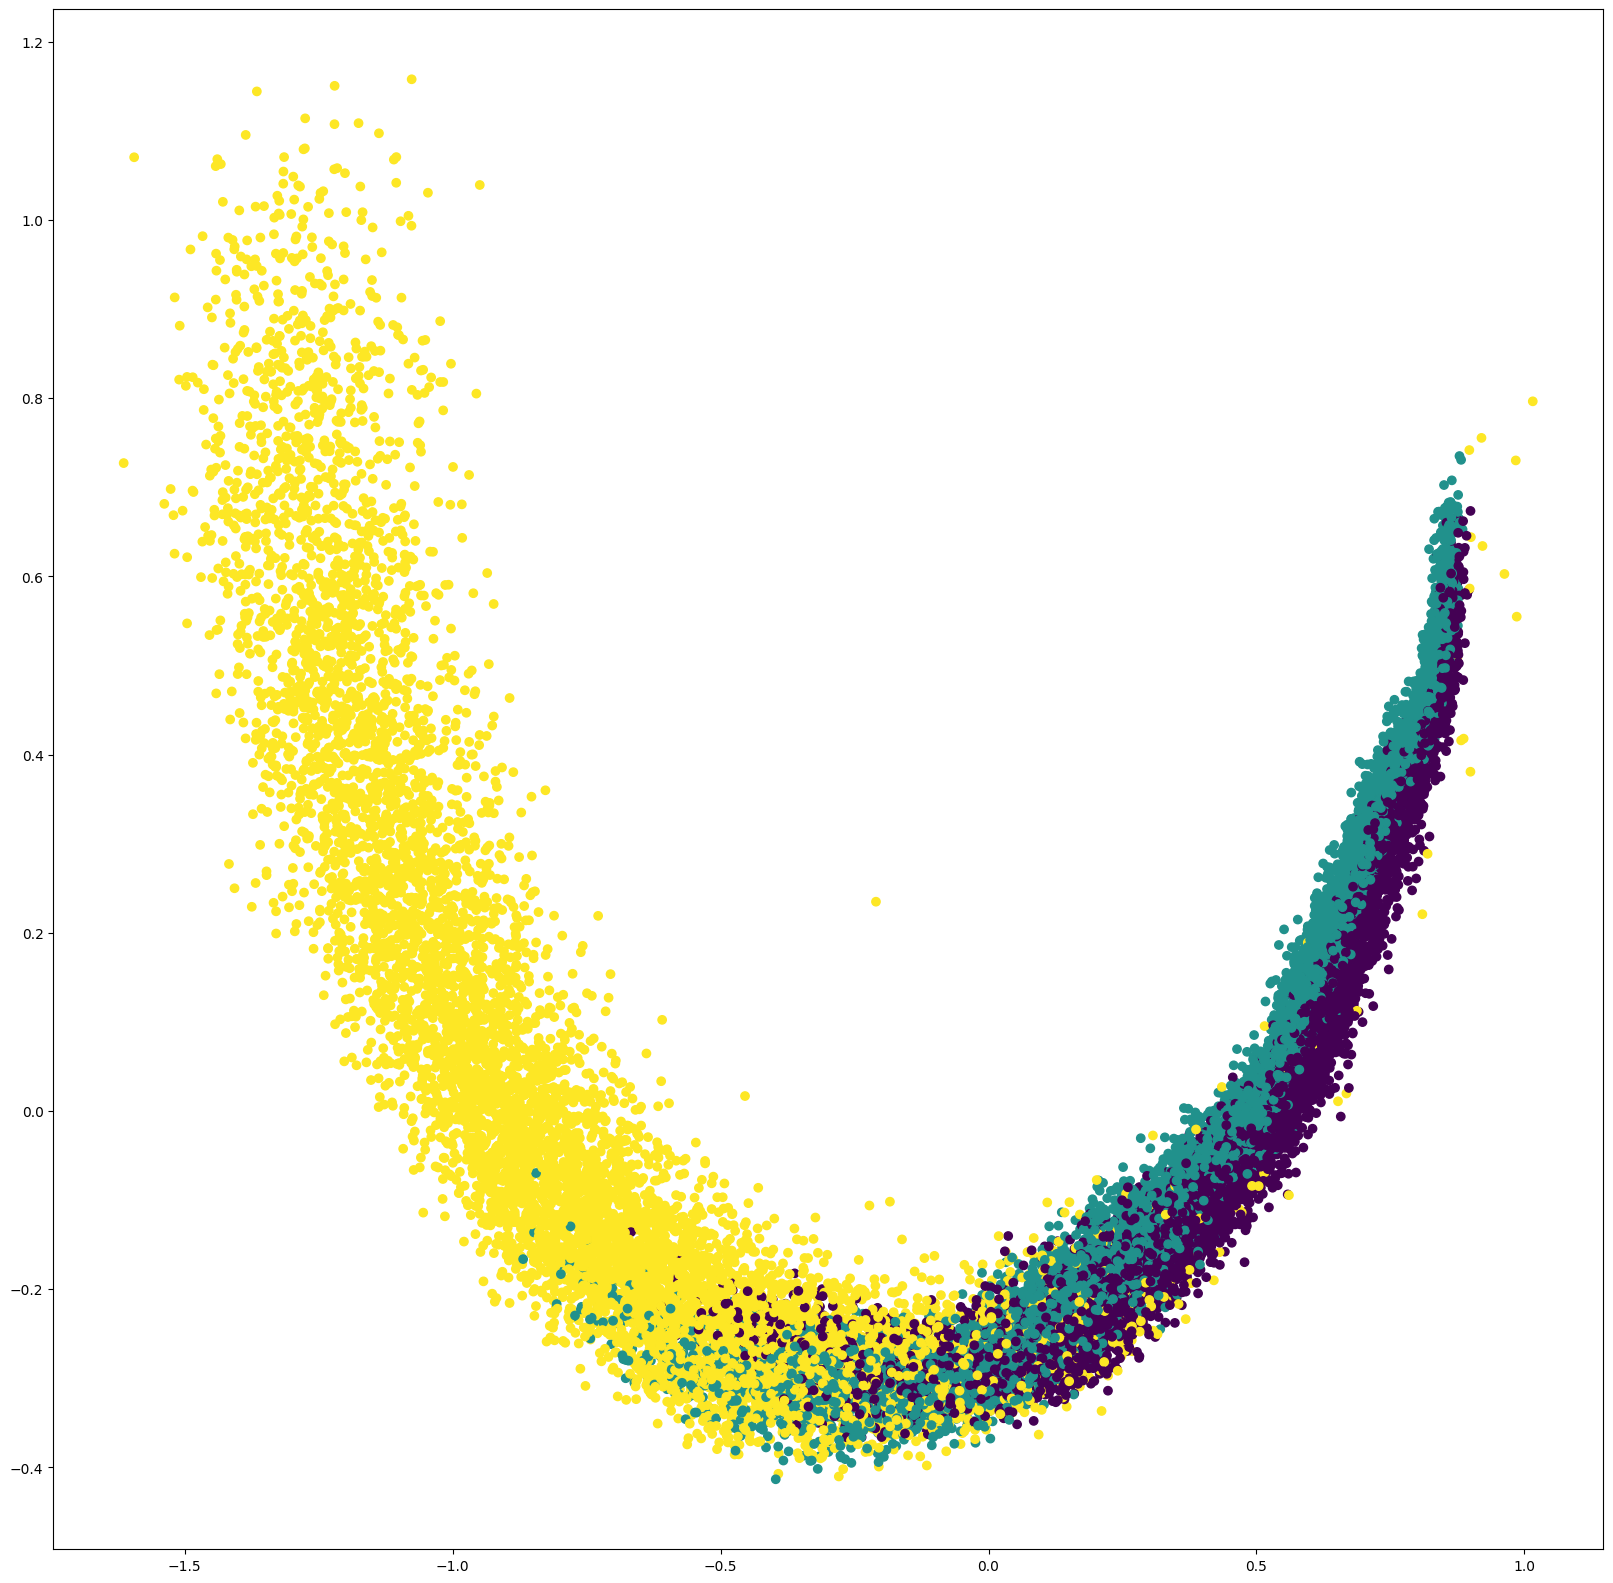

In [99]:
fig, ax = plt.subplots(figsize=(20,20))

ax.scatter(X_visual[:,0], X_visual[:,1], c=labels_numpy);

Сохраним метки для сабмита.

In [100]:
save_submission(labels_numpy, model_name='hdbscan')

Полученная для модели HDBSCAN метрика accuracy на Kaggle:

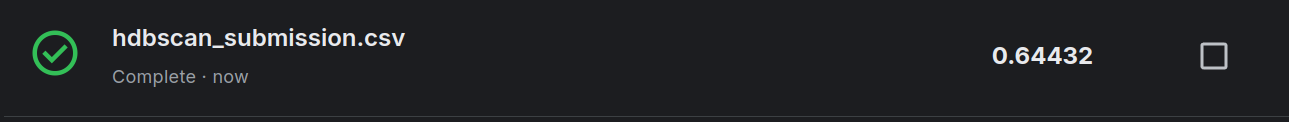

#### SpectralClustering (GPU-версия)

**ПРИМЕЧАНИЕ**: Весь код ниже для этого метода кластеризации работает только на GPU.

In [195]:
clusterer = cuml.cluster.SpectralClustering(
    n_clusters=3,
    n_components=10,
    n_neighbors=500,
    random_state=SEED)

labels = clusterer.fit_predict(gpu_df.copy())
labels_numpy = labels.to_numpy()
labels.value_counts()

1    18428
2     3905
0     1146
Name: count, dtype: int64

Отобразим диаграмму рассеяния точек в уменьшенном пространстве с цветовыми метками, соответствующими полученным меткам кластеров.

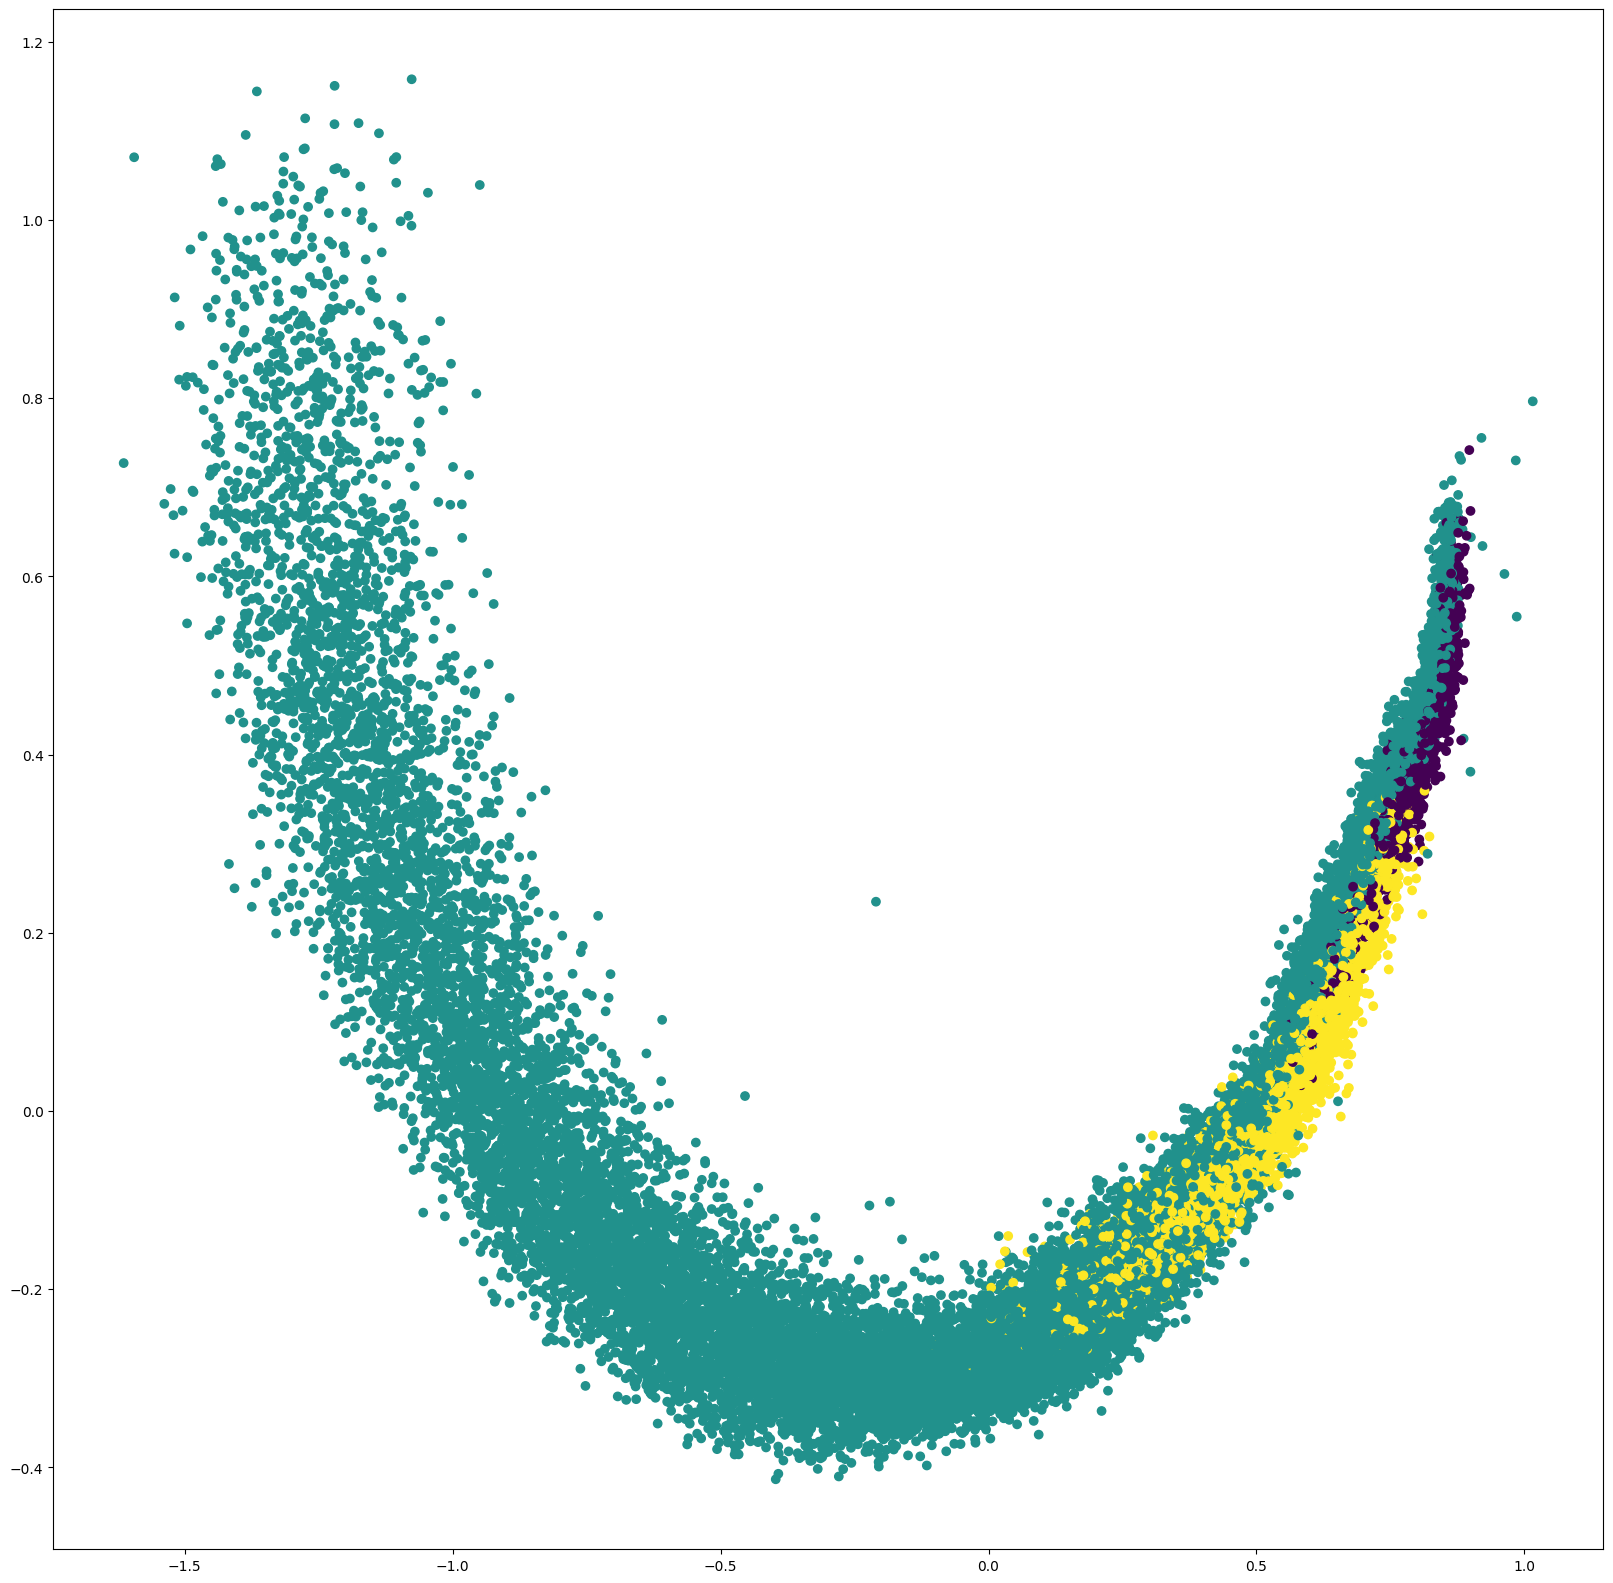

In [196]:
fig, ax = plt.subplots(figsize=(20,20))

ax.scatter(X_visual[:,0], X_visual[:,1], c=labels_numpy);

Сохраним метки для сабмита.

In [197]:
save_submission(labels_numpy, model_name='spectral')

Полученная для модели SpectralClustering метрика accuracy на Kaggle:

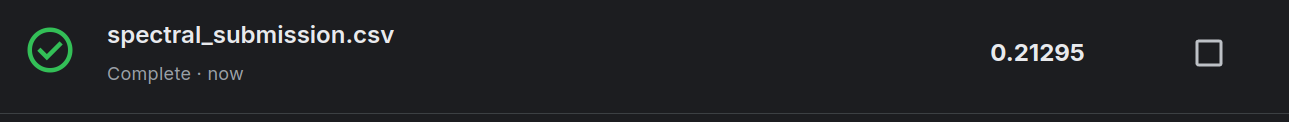

#### **Вывод**

HDBSCAN даёт наилучшее разделение на кластеры среди исследованных методов. Это соотносится с теоретическим обоснование этого метода, поскольку он очень хорошо умеет находить шумовые сэмплы.

## Скриншот лидерборда

Был получен в ходе одного из тестовых запусков метода HDBSCAN, без зафиксированного SEED.

С фиксированным SEED = 0 наилучшую метрику accuracy=0.64432 показал метод HDBSCAN (см. выше в подпункте, посвящённом подбору гиперпараметров для HDBSCAN).

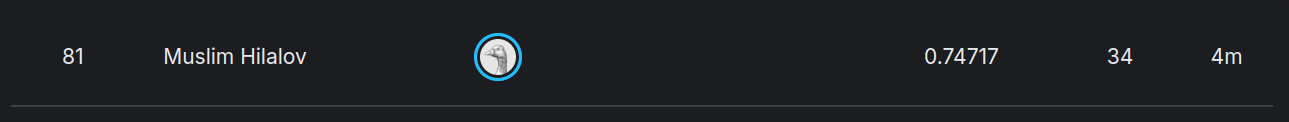